# CIENCIA DE LA COMPUTACION
### Facultad de Ciencias 
---
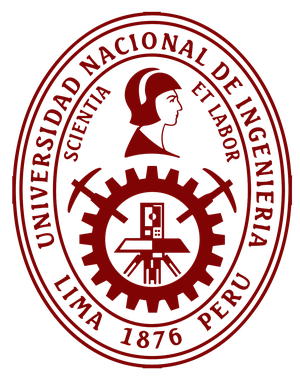
---

### Curso: Minería de Datos (CC442A)
### PC N°01: Condicionamiento Espectral y Estabilidad Numérica en el Preprocesamiento
---
---

### **Profesor:** Dr. Marco Antonio Alania Vicente
### **Estudiante:** César Omar López Arteaga

---
---

### 1. Introducción
El preprocesamiento de datos no es una mera limpieza empírica, sino un operador de transformación que actúa sobre el espectro de la matriz de datos $X \in \mathbb{R}^{n \times d}$. El dataset mal condicionado introduce inestabilidad, por lo que el objetivo de esta tarea es asegurar una matriz óptima algebraica y probabilísticamente.

### 2. Carga de Datos

Se carga el dataset de Arrhythmia.

El link del repositorio es: https://archive.ics.uci.edu/dataset/5/arrhythmia


Esta base de datos contiene 279 atributos, 206 de los cuales son de valores lineales y el resto nominales. 

Sobre el estudio de H. Altay Guvenir: "El objetivo es distinguir entre la presencia y ausencia de arritmias cardíacas y clasificarla en uno de los 16 grupos. La clase 01 se refiere a las clases de ECG 'normales' del 02 al 15, a diferentes clases de arritmia y la clase 16 al resto de las no clasificadas. Por el momento, existe un programa informático que realiza dicha clasificación. Sin embargo, existen diferencias entre la clasificación del cardiolog y el programa. Tomando los cardiologs como estándar de oro, buscamos minimizar esta diferencia mediante herramientas de aprendizaje automático."

# ¿Qué es una arritmia?

Una **arritmia** es una alteración en la generación o en la conducción de los impulsos eléctricos del corazón, que puede producir cambios en la **frecuencia**, el **ritmo** o la **secuencia de activación cardíaca**.

El principal procedimiento utilizado para estudiar estas alteraciones es el **electrocardiograma (ECG)**, el cual registra la actividad eléctrica del corazón mediante diferentes derivaciones o canales.

Entre las alteraciones del ritmo cardíaco más conocidas se encuentran:

- **Taquicardia:** frecuencia cardíaca anormalmente elevada. En un adulto en reposo suele considerarse taquicardia una frecuencia superior a aproximadamente 100 latidos por minuto.

- **Bradicardia:** frecuencia cardíaca inferior a aproximadamente 60 latidos por minuto en un adulto en reposo.

- **Latidos prematuros:** aparecen cuando una contracción cardíaca ocurre antes de lo esperado dentro del ciclo normal. Pueden ser, por ejemplo, contracciones ventriculares prematuras o supraventriculares.

- **Fibrilación o flutter auricular:** alteraciones de la actividad eléctrica de las aurículas que pueden producir un ritmo irregular o excesivamente rápido.

- **Bloqueos de conducción:** ocurren cuando el impulso eléctrico presenta dificultades para propagarse normalmente a través del corazón. Entre ellos se encuentran los bloqueos auriculoventriculares y los bloqueos de rama derecha o izquierda.

---
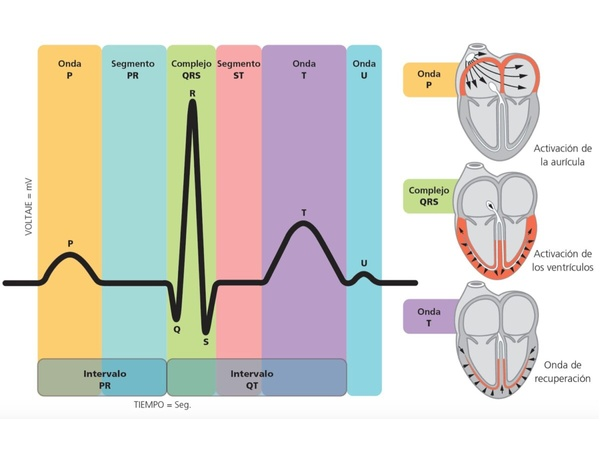

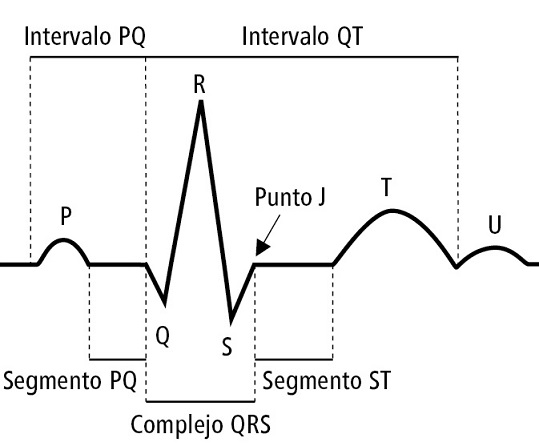

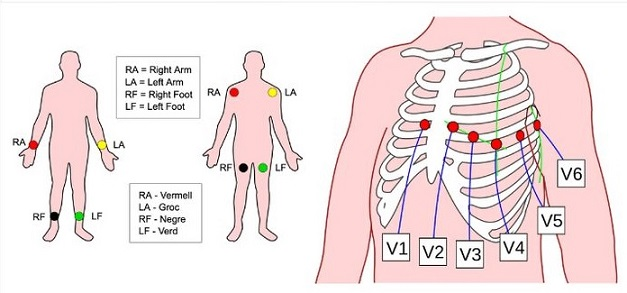


---

## Variables relevantes para el estudio de una arritmia

Una arritmia no se identifica únicamente observando la frecuencia cardíaca. El diagnóstico depende de diversas características extraídas del **electrocardiograma**, principalmente de la duración, amplitud, orientación y morfología de sus ondas.

Las principales variables consideradas en este dataset son:

### 1. Frecuencia cardíaca

La variable **Heart Rate** representa el número de latidos del corazón por minuto:

$$
HR = \text{número de latidos por minuto}.
$$

Esta variable permite identificar directamente comportamientos asociados a taquicardia o bradicardia.

---

### 2. Duración del complejo QRS

El **complejo QRS** representa principalmente la despolarización eléctrica de los ventrículos.

El dataset contiene la variable:

$$
\text{QRS duration}
$$

medida en milisegundos.

Una modificación importante de su duración puede estar asociada a alteraciones en la conducción ventricular, como los bloqueos de rama.

---

### 3. Intervalo P-R

El intervalo **P-R** mide aproximadamente el tiempo transcurrido desde el inicio de la activación eléctrica de las aurículas hasta el inicio de la activación ventricular.

En el dataset aparece como:

$$
\text{P-R interval}.
$$

Cambios en este intervalo pueden proporcionar información sobre problemas de conducción auriculoventricular.

---

### 4. Intervalo Q-T

El intervalo **Q-T** representa el tiempo comprendido entre el comienzo de la despolarización ventricular y el final de la repolarización ventricular.

El dataset contiene:

$$
\text{Q-T interval}.
$$

Por tanto, esta variable resume una parte importante de la actividad eléctrica ventricular.

---

### 5. Duración de las ondas P y T

También se registran las duraciones promedio de:

- **P interval:** duración de la onda P.
- **T interval:** duración de la onda T.

La onda **P** está relacionada principalmente con la despolarización auricular, mientras que la onda **T** está asociada con la repolarización ventricular.

---

### 6. Ángulos de los vectores eléctricos

La base de datos contiene los ángulos, medidos en grados sobre el plano frontal, correspondientes a:

$$
QRS,\quad T,\quad P,\quad QRST,\quad J.
$$

Estas variables describen la **dirección predominante de la actividad eléctrica del corazón**.

Por ejemplo, el ángulo del vector QRS proporciona información sobre la orientación global de la despolarización ventricular.

---

### 7. Morfología de las ondas del ECG

Para cada derivación se estudian características de diferentes componentes del electrocardiograma:

$$
Q,\quad R,\quad S,\quad R',\quad S',\quad P,\quad T.
$$

Entre las características registradas se encuentran:

- ancho de las ondas;
- amplitud de las ondas;
- existencia de ondas irregulares (*ragged*);
- existencia de ondas bifásicas;
- número de deflexiones intrínsecas.

Estas características permiten describir con mayor detalle la **forma del electrocardiograma**.

---

### 8. Derivaciones electrocardiográficas

Las mediciones anteriores no se realizan en un único punto del corazón. El dataset considera las 12 derivaciones electrocardiográficas:

$$
DI,\; DII,\; DIII,\; aVR,\; aVL,\; aVF,\; V1,\;V2,\;V3,\;V4,\;V5,\;V6.
$$

Cada derivación observa la actividad eléctrica cardíaca desde una orientación diferente.

Por esta razón, una misma onda puede presentar diferentes amplitudes y formas dependiendo del canal desde el cual sea observada.

---

### 9. Áreas QRSA y QRSTA

Además de las amplitudes individuales, el dataset contiene variables que resumen el área de determinados segmentos del electrocardiograma:

- **QRSA:** área asociada a los segmentos del complejo QRS.
- **QRSTA:** extensión de QRSA incorporando información de la onda T.

Estas variables proporcionan una medida adicional de la geometría de la señal eléctrica.

---



## Estructura del dataset

La base de datos utilizada corresponde a **Cardiac Arrhythmia Database** y contiene:

$$
\boxed{452\text{ pacientes}}
$$

descritos inicialmente mediante:

$$
\boxed{279\text{ atributos}}
$$

de los cuales existen variables continuas y variables nominales. La variable objetivo se encuentra dividida en **16 clases**. 

Por tanto, cada paciente puede representarse matemáticamente mediante un vector de características

$$
\mathbf{x}_i =
(x_{i1},x_{i2},\ldots,x_{i279})
\in\mathbb{R}^{279},
$$

junto con una etiqueta de clase

$$
y_i\in\{1,2,\ldots,16\}.
$$

De esta manera, inicialmente podemos representar el problema mediante una matriz de datos

$$
X\in\mathbb{R}^{452\times279},
$$

y un vector de etiquetas

$$
\mathbf{y}\in\{1,\ldots,16\}^{452}.
$$

### Descripción de las variables del dataset Arrhythmia

| Variable | Significado | Interpretación / valores |
|---|---|---|
| `age` (1) | Edad | Edad del paciente en años |
| `sex` (2) | Sexo | `0` = hombre, `1` = mujer |
| `height` (3) | Altura | Altura del paciente en centímetros |
| `weight` (4) | Peso | Peso del paciente en kilogramos |
| `qrs_duration` (5) | Duración QRS | Duración promedio del complejo QRS en milisegundos |
| `pr_interval` (6) | Intervalo P-R | Tiempo promedio entre el inicio de las ondas P y Q, en ms |
| `qt_interval` (7) | Intervalo Q-T | Tiempo promedio entre el inicio de Q y el final de T, en ms |
| `t_interval` (8) | Duración de onda T | Duración promedio de la onda T, en ms |
| `p_interval` (9) | Duración de onda P | Duración promedio de la onda P, en ms |
| `qrs_angle` (10) | Ángulo QRS | Ángulo del vector QRS en el plano frontal, en grados |
| `t_angle` (11) | Ángulo T | Ángulo del vector de la onda T, en grados |
| `p_angle` (12) | Ángulo P | Ángulo del vector de la onda P, en grados |
| `qrst_angle` (13) | Ángulo QRST | Ángulo del vector QRST en el plano frontal |
| `j_angle` (14) | Ángulo J | Ángulo del vector J en el plano frontal |
| `heart_rate` (15) | Frecuencia cardíaca | Número de latidos del corazón por minuto |
| `Variable_16` – `Variable_27` | Características de la derivación DI | Anchuras de Q, R, S, R', S'; número de deflexiones intrínsecas y características morfológicas de las ondas R, P y T |
| `Variable_28` – `Variable_39` | Características de la derivación DII | Mismas 12 características de forma y anchura medidas en DII |
| `Variable_40` – `Variable_51` | Características de la derivación DIII | Mismas 12 características medidas en DIII |
| `Variable_52` – `Variable_63` | Características de la derivación AVR | Mismas 12 características medidas en AVR |
| `Variable_64` – `Variable_75` | Características de la derivación AVL | Mismas 12 características medidas en AVL |
| `Variable_76` – `Variable_87` | Características de la derivación AVF | Mismas 12 características medidas en AVF |
| `Variable_88` – `Variable_99` | Características de la derivación V1 | Mismas 12 características medidas en V1 |
| `Variable_100` – `Variable_111` | Características de la derivación V2 | Mismas 12 características medidas en V2 |
| `Variable_112` – `Variable_123` | Características de la derivación V3 | Mismas 12 características medidas en V3 |
| `Variable_124` – `Variable_135` | Características de la derivación V4 | Mismas 12 características medidas en V4 |
| `Variable_136` – `Variable_147` | Características de la derivación V5 | Mismas 12 características medidas en V5 |
| `Variable_148` – `Variable_159` | Características de la derivación V6 | Mismas 12 características medidas en V6 |
| `Variable_160` – `Variable_169` | Amplitudes en DI | Amplitudes de las ondas JJ, Q, R, S, R', S', P y T; además de QRSA y QRSTA |
| `Variable_170` – `Variable_179` | Amplitudes en DII | Mismas 10 características de amplitud medidas en DII |
| `Variable_180` – `Variable_189` | Amplitudes en DIII | Mismas 10 características de amplitud medidas en DIII |
| `Variable_190` – `Variable_199` | Amplitudes en AVR | Mismas 10 características de amplitud medidas en AVR |
| `Variable_200` – `Variable_209` | Amplitudes en AVL | Mismas 10 características de amplitud medidas en AVL |
| `Variable_210` – `Variable_219` | Amplitudes en AVF | Mismas 10 características de amplitud medidas en AVF |
| `Variable_220` – `Variable_229` | Amplitudes en V1 | Mismas 10 características de amplitud medidas en V1 |
| `Variable_230` – `Variable_239` | Amplitudes en V2 | Mismas 10 características de amplitud medidas en V2 |
| `Variable_240` – `Variable_249` | Amplitudes en V3 | Mismas 10 características de amplitud medidas en V3 |
| `Variable_250` – `Variable_259` | Amplitudes en V4 | Mismas 10 características de amplitud medidas en V4 |
| `Variable_260` – `Variable_269` | Amplitudes en V5 | Mismas 10 características de amplitud medidas en V5 |
| `Variable_270` – `Variable_279` | Amplitudes en V6 | Mismas 10 características de amplitud medidas en V6 |
| `Clase` | **Variable objetivo** | Clase diagnóstica del ECG: `1` = normal, `2–15` = diferentes tipos de arritmia, `16` = otras arritmias |

### Variable objetivo: `Clase`

| Clase | Diagnóstico |
|---:|---|
| `1` | ECG normal |
| `2` | Cambios isquémicos / enfermedad arterial coronaria |
| `3` | Infarto de miocardio anterior antiguo |
| `4` | Infarto de miocardio inferior antiguo |
| `5` | Taquicardia sinusal |
| `6` | Bradicardia sinusal |
| `7` | Contracción ventricular prematura (PVC) |
| `8` | Contracción supraventricular prematura |
| `9` | Bloqueo de rama izquierda |
| `10` | Bloqueo de rama derecha |
| `11` | Bloqueo auriculoventricular de primer grado |
| `12` | Bloqueo auriculoventricular de segundo grado |
| `13` | Bloqueo auriculoventricular de tercer grado |
| `14` | Hipertrofia ventricular izquierda |
| `15` | Fibrilación o flutter auricular |
| `16` | Otras arritmias |

## 2. Carga, auditoría y tratamiento previo de valores faltantes

Siguiendo el flujo solicitado, primero se trabaja con la matriz completa de predictores `X_raw`:

1. Se detectan y cuantifican los valores faltantes.
2. Se elimina `j_angle` por su porcentaje extremo de ausencia.
3. Se imputan los faltantes restantes y se verifica que la matriz final no contenga `NaN`.
4. **Recién después** se realiza el particionamiento estratificado en `Train` y `Test`.

Los símbolos `?` del archivo original se interpretan como `NaN`.

> **Nota metodológica.** Este orden usa toda la matriz de predictores para estimar la imputación antes del *split*. Se conserva porque es el flujo solicitado para esta tarea. En una evaluación predictiva estricta, el imputador normalmente se ajusta solo con `Train` para evitar *data leakage*.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=5, suppress=True)
pd.set_option("display.max_rows", 30)
pd.set_option("display.max_columns", 20)

# ruta de data
DATA_PATH = Path("arrhythmia.data")
if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/arrhythmia.data")

# nombres descriptivos de los 279 atributos de UCI
feature_names = [
    "age", "sex", "height", "weight", "qrs_duration", "pr_interval",
    "qt_interval", "t_interval", "p_interval", "qrs_angle", "t_angle",
    "p_angle", "qrst_angle", "j_angle", "heart_rate"
]

leads = ["DI", "DII", "DIII", "AVR", "AVL", "AVF", "V1", "V2", "V3", "V4", "V5", "V6"]
shape_features = [
    "q_width", "r_width", "s_width", "r_prime_width", "s_prime_width",
    "intrinsic_deflections", "ragged_R", "diphasic_R", "ragged_P",
    "diphasic_P", "ragged_T", "diphasic_T"
]
amplitude_features = [
    "JJ_amp", "Q_amp", "R_amp", "S_amp", "R_prime_amp", "S_prime_amp",
    "P_amp", "T_amp", "QRSA", "QRSTA"
]

for lead in leads:
    feature_names.extend([f"{lead}_{f}" for f in shape_features])
for lead in leads:
    feature_names.extend([f"{lead}_{f}" for f in amplitude_features])

assert len(feature_names) == 279

df = pd.read_csv(DATA_PATH, header=None, na_values="?")
df.columns = feature_names + ["Clase"]

X_raw = df[feature_names].copy()
y_raw = df["Clase"].copy()

print("Dimensión total del dataset:", df.shape)
print("Matriz de predictores X_raw:", X_raw.shape)
print("Vector objetivo y_raw:", y_raw.shape)
print("\nPrimeras observaciones:")
display(df.head())

Dimensión total del dataset: (452, 280)
Matriz de predictores X_raw: (452, 279)
Vector objetivo y_raw: (452,)

Primeras observaciones:


,age,sex,height,weight,qrs_duration,pr_interval,qt_interval,t_interval,p_interval,qrs_angle,...,V6_Q_amp,V6_R_amp,V6_S_amp,V6_R_prime_amp,V6_S_prime_amp,V6_P_amp,V6_T_amp,V6_QRSA,V6_QRSTA,Clase
0,75,0,190,80,91,193,371,174,121,-16,...,0.0,9.0,-0.9,0.0,0.0,0.9,2.9,23.3,49.4,8
1,56,1,165,64,81,174,401,149,39,25,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6
2,54,0,172,95,138,163,386,185,102,96,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10
3,55,0,175,94,100,202,380,179,143,28,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1
4,75,0,190,80,88,181,360,177,103,-16,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7


### 2.1 Auditoría correcta de valores faltantes

La exploración original confundía **índices de columnas** con filas. En realidad, los faltantes están concentrados en cinco atributos clínicos:

- `t_angle`: 8 faltantes.
- `p_angle`: 22 faltantes.
- `qrst_angle`: 1 faltante.
- `j_angle`: 376 faltantes.
- `heart_rate`: 1 faltante.

La columna crítica es `j_angle`: faltan aproximadamente el **83.19 %** de sus valores. Si elimináramos todas las filas que contienen algún faltante, se perdería aproximadamente el **85 %** de los pacientes, principalmente por esta sola variable. Esa alternativa destruiría el tamaño muestral y podría alterar la distribución de clases.

Por ello, la decisión metodológica será **eliminar `j_angle` como atributo**, no eliminar masivamente pacientes. Los otros cuatro atributos tienen una fracción de ausencia pequeña y sí se intentarán reconstruir mediante información multivariada.

,faltantes,porcentaje_%
j_angle,376,83.186
p_angle,22,4.867
t_angle,8,1.770
qrst_angle,1,0.221
heart_rate,1,0.221


Filas con al menos un faltante: 384/452 (84.96%)
Filas con faltantes después de retirar j_angle: 32/452 (7.08%)


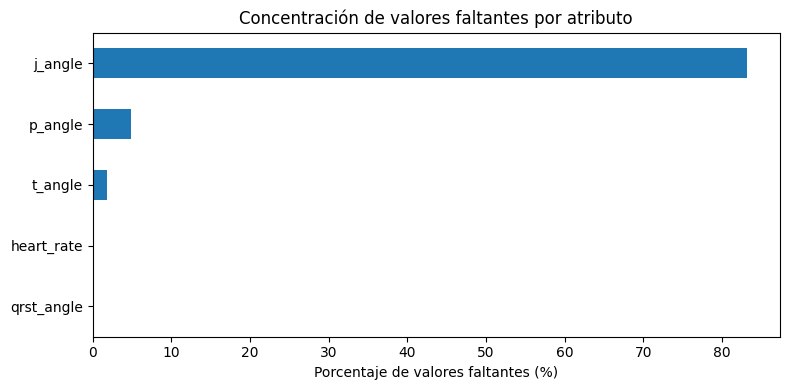

In [2]:
#cuenta los valores faltantes por columna
missing_count = X_raw.isna().sum()

#creacion del dataframe con el reporte de valores faltantes
missing_report = pd.DataFrame({
    "faltantes": missing_count[missing_count > 0],
    "porcentaje_%": 100 * missing_count[missing_count > 0] / len(X_raw)
}).sort_values("porcentaje_%", ascending=False)

#imprime el reporte de valores faltantes
display(missing_report.round(3))

#cuenta las filas con al menos un faltante
rows_any_missing = X_raw.isna().any(axis=1).sum()

#elimina la columna j_angle y cuenta las filas con al menos un faltante
rows_any_missing_without_j = X_raw.drop(columns=["j_angle"]).isna().any(axis=1).sum()

print(f"Filas con al menos un faltante: {rows_any_missing}/{len(X_raw)} "
      f"({100*rows_any_missing/len(X_raw):.2f}%)")
print(f"Filas con faltantes después de retirar j_angle: {rows_any_missing_without_j}/{len(X_raw)} "
      f"({100*rows_any_missing_without_j/len(X_raw):.2f}%)")

#impresion del grafico de concentracion de valores faltantes por atributo
plt.figure(figsize=(8, 4))
missing_report["porcentaje_%"].sort_values().plot(kind="barh")
plt.xlabel("Porcentaje de valores faltantes (%)")
plt.title("Concentración de valores faltantes por atributo")
plt.tight_layout()
plt.show()

## 3. C) Tratamiento de valores faltantes antes de la estratificación

> Esta etapa se ejecuta sobre `X_raw` completo. Al finalizar se construirá `X_complete`, una matriz sin valores faltantes. Solo después se realizará la estratificación.

### 3.1 MCAR, MAR y MNAR: qué puede afirmarse con los datos

Sea \(R_j=1\) si el atributo \(X_j\) está ausente y \(R_j=0\) si está observado.

- **MCAR:** \(P(R_j=1\mid X_{obs},X_{miss})=P(R_j=1)\).
- **MAR:** \(P(R_j=1\mid X_{obs},X_{miss})=P(R_j=1\mid X_{obs})\).
- **MNAR:** la ausencia depende del propio valor no observado, aun condicionando por \(X_{obs}\).

Con una sola base observacional no es posible demostrar MNAR únicamente a partir de los datos disponibles, porque el valor que explicaría su ausencia no se observa. Sí podemos buscar evidencia contra MCAR: si el indicador de ausencia está asociado con variables observadas, MCAR deja de ser plausible y MAR se vuelve una hipótesis de trabajo razonable.

En `j_angle` la ausencia supera 80 %. Con tan pocas observaciones reales, una imputación multivariada tendría una incertidumbre demasiado grande y podría crear estructura artificial. Por ello se elimina este atributo antes de completar el resto de la matriz.


In [3]:
# Diagnóstico de asociación entre el indicador de ausencia y variables observadas.
# Se aplica ANTES de la estratificación, sobre X_raw completo.
def missingness_association_report(X):
    rows = []

    # Predictores que están completamente observados y tienen variación.
    complete_predictors = [
        c for c in X.columns
        if (not X[c].isna().any()) and X[c].nunique(dropna=True) > 1
    ]

    # Se analiza cada atributo que contiene al menos un NaN.
    for target in X.columns[X.isna().any()]:
        R = X[target].isna().astype(float)

        correlations = []
        for c in complete_predictors:
            corr = R.corr(X[c])
            if pd.notna(corr):
                correlations.append((abs(corr), corr, c))

        if correlations:
            abs_corr, corr, predictor = max(correlations)
        else:
            abs_corr, corr, predictor = np.nan, np.nan, None

        rows.append({
            "atributo_faltante": target,
            "faltantes": int(R.sum()),
            "tasa_faltante_%": 100 * R.mean(),
            "predictor_observado_mas_asociado": predictor,
            "corr(R, predictor)": corr,
            "|corr|": abs_corr,
        })

    return pd.DataFrame(rows).sort_values("tasa_faltante_%", ascending=False)


assoc = missingness_association_report(X_raw)
display(assoc.round(4))


,atributo_faltante,faltantes,tasa_faltante_%,predictor_observado_mas_asociado,"corr(R, predictor)",|corr|
3,j_angle,376,83.1858,qrs_duration,-0.3882,0.3882
1,p_angle,22,4.8673,AVR_P_amp,0.4207,0.4207
0,t_angle,8,1.7699,DIII_diphasic_T,0.2439,0.2439
2,qrst_angle,1,0.2212,DIII_ragged_T,0.4452,0.4452
4,heart_rate,1,0.2212,V1_q_width,0.1325,0.1325


### 3.2 Decisión de conservación/eliminación

La estrategia se aplica **antes del particionamiento estratificado**:

1. **Eliminar `j_angle`**: su tasa de ausencia es extrema; imputarlo significaría que la mayor parte de la columna sería generada artificialmente.
2. **No eliminar filas** por los faltantes restantes: después de retirar `j_angle`, solo una fracción pequeña de pacientes conserva valores ausentes.
3. **Eliminar atributos constantes o degenerados**: no aportan variabilidad y generan singularidad en matrices de covarianza/Gram.
4. **Imputar `t_angle`, `p_angle`, `qrst_angle` y `heart_rate` mediante un MICE básico propio**, utilizando las relaciones multivariadas disponibles en `X_raw`.

El objetivo de esta etapa es producir

\[
\boxed{X_{\mathrm{complete}}\in\mathbb{R}^{452\times d}}
\]

sin valores faltantes, y recién entonces efectuar la estratificación.


In [4]:
# 1) Eliminar columnas con ausencia extrema sobre la base completa.
high_missing_threshold = 0.50
high_missing_cols = [
    c for c in X_raw.columns
    if X_raw[c].isna().mean() >= high_missing_threshold
]

print("Columnas eliminadas por ausencia >= 50%:")
print(high_missing_cols)

X_stage = X_raw.drop(columns=high_missing_cols).copy()

# 2) Eliminar columnas constantes/degeneradas ANTES de la estratificación.
constant_cols = [
    c for c in X_stage.columns
    if X_stage[c].nunique(dropna=True) <= 1
]

print(f"\nColumnas constantes eliminadas: {len(constant_cols)}")
print(constant_cols)

X_stage = X_stage.drop(columns=constant_cols).copy()

# 3) Identificar las columnas que todavía contienen valores faltantes.
cols_to_impute = [
    c for c in X_stage.columns
    if X_stage[c].isna().any()
]

print("\nColumnas a imputar:")
print(cols_to_impute)

print("\nFaltantes antes de imputar:")
display(
    X_stage[cols_to_impute]
    .isna()
    .sum()
    .rename("faltantes")
    .to_frame()
)

print("\nTotal de NaN antes de imputar:", int(X_stage.isna().sum().sum()))
print("Dimensión de X_stage:", X_stage.shape)


Columnas eliminadas por ausencia >= 50%:
['j_angle']

Columnas constantes eliminadas: 17
['DI_s_prime_width', 'AVL_s_prime_width', 'AVL_ragged_R', 'AVF_ragged_P', 'V4_ragged_P', 'V4_diphasic_P', 'V5_s_prime_width', 'V5_ragged_R', 'V5_ragged_P', 'V5_ragged_T', 'V6_s_prime_width', 'V6_diphasic_P', 'V6_ragged_T', 'DI_S_prime_amp', 'AVL_S_prime_amp', 'V5_S_prime_amp', 'V6_S_prime_amp']

Columnas a imputar:
['t_angle', 'p_angle', 'qrst_angle', 'heart_rate']

Faltantes antes de imputar:


,faltantes
t_angle,8
p_angle,22
qrst_angle,1
heart_rate,1



Total de NaN antes de imputar: 32
Dimensión de X_stage: (452, 261)


### 3.3 Demostración matemática de la trampa de la media y del colapso de varianza

Sean $x_1,\ldots,x_n$ los valores observados de una variable, con media

$$
\mu=\frac{1}{n}\sum_{i=1}^{n}x_i,
$$

y supongamos que existen $m$ valores faltantes. Si todos se reemplazan por $\mu$, la nueva media sigue siendo $\mu$ porque

$$
\mu_{new}=\frac{\sum_{i=1}^{n}x_i+m\mu}{n+m}
=\frac{n\mu+m\mu}{n+m}=\mu.
$$

Sin embargo, los $m$ valores imputados aportan desviación cero respecto de la media. Usando la **varianza poblacional**,

$$
\sigma^2_{obs}=\frac{1}{n}\sum_{i=1}^{n}(x_i-\mu)^2,
$$

se obtiene

$$
\begin{aligned}
\sigma^2_{new}
&=\frac{1}{n+m}
\left[
\sum_{i=1}^{n}(x_i-\mu)^2
+\sum_{k=1}^{m}(\mu-\mu)^2
\right]\\
&=\frac{1}{n+m}\sum_{i=1}^{n}(x_i-\mu)^2\\
&=\boxed{\frac{n}{n+m}\sigma^2_{obs}}.
\end{aligned}
$$

Como $n/(n+m)<1$ para $m>0$, la varianza disminuye necesariamente. Esta es la **trampa de la media**: preserva el primer momento, pero comprime el segundo momento y además debilita covarianzas con otras variables.

Si se utiliza la varianza muestral con divisor $n-1$, el factor exacto cambia a

$$
 s^2_{new}=\frac{n-1}{n+m-1}s^2_{obs},
$$

pero la conclusión es la misma: la dispersión colapsa.


In [6]:
# Demostración empírica de la reducción de varianza al imputar por la media.
# Se usa la base completa ANTES de la estratificación.
var_demo = "p_angle"

observed = X_stage[var_demo].dropna().to_numpy(dtype=float)
n_obs = observed.size
m_miss = int(X_stage[var_demo].isna().sum())

mu_obs = observed.mean()
var_obs_pop = np.var(observed, ddof=0)

mean_imputed = X_stage[var_demo].fillna(mu_obs).to_numpy(dtype=float)
var_mean_imp_pop = np.var(mean_imputed, ddof=0)

var_formula = n_obs / (n_obs + m_miss) * var_obs_pop

print(f"Variable elegida: {var_demo}")
print(f"n observados = {n_obs}, m faltantes = {m_miss}")
print(f"Varianza observada               = {var_obs_pop:.6f}")
print(f"Varianza tras imputar con media  = {var_mean_imp_pop:.6f}")
print(f"Predicción n/(n+m)*var_obs       = {var_formula:.6f}")
print(f"Error numérico                   = {abs(var_mean_imp_pop-var_formula):.3e}")


Variable elegida: p_angle
n observados = 430, m faltantes = 22
Varianza observada               = 859.208875
Varianza tras imputar con media  = 817.388974
Predicción n/(n+m)*var_obs       = 817.388974
Error numérico                   = 1.137e-13


### 3.4 MICE básico propio con NumPy/Pandas

La imputación se trata como un problema predictivo multivariado. Para cada atributo incompleto \(X_j\) se modela

\[
X_j \approx \beta_0+\sum_{k\in S_j}\beta_k X_k,
\]

donde \(S_j\) contiene los predictores más correlacionados con \(X_j\).

El procedimiento es:

- inicialización temporal mediante la mediana;
- selección de un número moderado de predictores correlacionados;
- estandarización interna de los predictores;
- regularización Ridge pequeña;
- actualización iterativa por ecuaciones encadenadas;
- adición estocástica de residuos para no colapsar todos los valores imputados sobre una única predicción;
- recorte al rango observado.

En esta versión el ajuste se realiza sobre `X_stage` **antes de la estratificación**, y su salida final es `X_complete`.


In [7]:
def _abs_corr(x, y):
    """Correlación absoluta, robusta al caso de varianza cero."""
    if np.std(x) < 1e-12 or np.std(y) < 1e-12:
        return 0.0
    return abs(np.corrcoef(x, y)[0, 1])


def fit_mice_numpy(
    X,
    target_cols,
    n_iter=8,
    top_k=12,
    ridge=1e-2,
    seed=123,
):
    """
    Imputa un esquema MICE básico sobre una matriz X.

    Parámetros
    ----------
    X : DataFrame
        Matriz de predictores con algunos NaN.
    target_cols : list
        Columnas que serán imputadas.
    n_iter : int
        Número de iteraciones de ecuaciones encadenadas.
    top_k : int
        Número máximo de predictores por modelo.
    ridge : float
        Regularización para estabilizar las ecuaciones normales.
    seed : int
        Semilla para la imputación estocástica.

    Retorna
    -------
    X_imputed : DataFrame
        Matriz completa, con los faltantes imputados.
    state : dict
        Información de los modelos ajustados.
    """
    rng = np.random.default_rng(seed)

    X0 = X.astype(float).copy()
    original_missing = X0.isna().copy()

    # Inicialización temporal con la mediana de cada atributo.
    medians = X0.median(axis=0)
    X_work = X0.fillna(medians)

    models = {}

    for _ in range(n_iter):
        for target in target_cols:
            if target not in X_work.columns:
                continue

            observed_mask = ~original_missing[target]
            y_obs = X0.loc[observed_mask, target].to_numpy(dtype=float)

            # Si hubiese muy pocos observados, queda la inicialización por mediana.
            if y_obs.size < max(10, top_k + 3):
                continue

            candidates = [
                c for c in X_work.columns
                if c != target
                and X_work.loc[observed_mask, c].std(ddof=0) > 1e-12
            ]

            scores = []
            for c in candidates:
                x_c = X_work.loc[observed_mask, c].to_numpy(dtype=float)
                scores.append((_abs_corr(x_c, y_obs), c))

            predictors = [c for _, c in sorted(scores, reverse=True)[:top_k]]

            A = X_work.loc[observed_mask, predictors].to_numpy(dtype=float)
            mu_x = A.mean(axis=0)
            sd_x = A.std(axis=0, ddof=0)
            sd_x = np.where(sd_x < 1e-12, 1.0, sd_x)

            Z = (A - mu_x) / sd_x

            y_mean = y_obs.mean()
            y_centered = y_obs - y_mean

            # Ridge: (Z^T Z + lambda I) beta = Z^T y
            gram = Z.T @ Z + ridge * np.eye(Z.shape[1])
            beta = np.linalg.solve(gram, Z.T @ y_centered)

            fitted = y_mean + Z @ beta
            residuals = y_obs - fitted

            lo, hi = y_obs.min(), y_obs.max()

            models[target] = {
                "predictors": predictors,
                "mu_x": mu_x,
                "sd_x": sd_x,
                "y_mean": y_mean,
                "beta": beta,
                "residuals": residuals.copy(),
                "lo": lo,
                "hi": hi,
            }

            # Reimputar solo las posiciones que originalmente eran NaN.
            missing_mask = original_missing[target]

            if missing_mask.any():
                A_miss = X_work.loc[missing_mask, predictors].to_numpy(dtype=float)
                Z_miss = (A_miss - mu_x) / sd_x
                pred = y_mean + Z_miss @ beta

                # Componente estocástica para preservar variabilidad.
                if residuals.size > 0:
                    pred = pred + rng.choice(
                        residuals,
                        size=pred.size,
                        replace=True
                    )

                pred = np.clip(pred, lo, hi)
                X_work.loc[missing_mask, target] = pred

    state = {
        "medians": medians,
        "models": models,
        "target_cols": list(target_cols),
        "n_iter": n_iter,
    }

    return X_work, state


# ---------------------------------------------------------------
# COMPLETACIÓN DE TODA LA DATA ANTES DE HACER LA ESTRATIFICACIÓN
# ---------------------------------------------------------------
X_complete, mice_state = fit_mice_numpy(
    X_stage,
    cols_to_impute,
    n_iter=8,
    top_k=12,
    ridge=1e-2,
    seed=123,
)

total_missing_final = int(X_complete.isna().sum().sum())

print("Faltantes finales en X_complete:", total_missing_final)
print("Dimensión final de X_complete :", X_complete.shape)

assert total_missing_final == 0, "X_complete todavía contiene valores faltantes."


Faltantes finales en X_complete: 0
Dimensión final de X_complete : (452, 261)


### 3.5 Verificación: media vs. MICE

No se exige que MICE reproduzca exactamente la varianza de los valores no observados —estos son desconocidos—, pero sí se busca evitar el colapso determinista causado por reemplazar todos los faltantes por una única constante.

La tabla compara, **antes de estratificar**:

- varianza de los valores realmente observados;
- varianza después de imputar por media;
- varianza después de la imputación MICE.

Finalmente se verifica explícitamente que

\[
\boxed{\sum_{i,j}\mathbf{1}\{X_{\mathrm{complete},ij}\text{ es NaN}\}=0}.
\]


In [8]:
variance_comparison = []

for c in cols_to_impute:
    observed = X_stage[c].dropna().to_numpy(dtype=float)

    mean_value = X_stage[c].mean()
    mean_imp = X_stage[c].fillna(mean_value).to_numpy(dtype=float)

    mice_imp = X_complete[c].to_numpy(dtype=float)

    variance_comparison.append({
        "atributo": c,
        "faltantes_originales": int(X_stage[c].isna().sum()),
        "var_observada": np.var(observed, ddof=0),
        "var_media": np.var(mean_imp, ddof=0),
        "var_MICE": np.var(mice_imp, ddof=0),
    })

variance_report = pd.DataFrame(variance_comparison)

display(variance_report.round(5))

print(
    "\nTotal de faltantes después del tratamiento:",
    int(X_complete.isna().sum().sum())
)

assert not X_complete.isna().any().any()


,atributo,faltantes_originales,var_observada,var_media,var_MICE
0,t_angle,8,3340.03804,3280.92232,3291.83520
1,p_angle,22,859.20888,817.38897,871.22927
2,qrst_angle,1,1294.61568,1291.75149,1291.89682
3,heart_rate,1,191.96928,191.54457,191.93930



Total de faltantes después del tratamiento: 0


## 4. Particionamiento estratificado después de completar la data

En este punto ya se dispone de

\[
\boxed{X_{\mathrm{complete}}}
\]

sin valores faltantes. **Recién ahora** se realiza la separación estratificada.

El dataset está desbalanceado y varias clases poseen muy pocos ejemplos. Para conservar aproximadamente la distribución de `Clase`:

1. se agrupan los índices por clase;
2. se barajan con una semilla fija;
3. se reserva aproximadamente el 20 % de cada clase para `Test`;
4. se conserva al menos una observación en `Train` cuando la clase tiene más de un registro.

La estratificación se aplica a `X_complete` y `y_raw`, no a `X_raw`.


In [9]:
def stratified_split_numpy(X, y, test_size=0.20, seed=42):
    rng = np.random.default_rng(seed)
    train_idx, test_idx = [], []
    y_arr = y.to_numpy()

    for clase in np.sort(y.unique()):
        idx = np.where(y_arr == clase)[0]
        rng.shuffle(idx)
        n_c = len(idx)

        if n_c <= 1:
            n_test = 0
        else:
            n_test = int(round(test_size * n_c))
            n_test = max(1, n_test)
            n_test = min(n_test, n_c - 1)

        test_idx.extend(idx[:n_test])
        train_idx.extend(idx[n_test:])

    train_idx = np.array(train_idx, dtype=int)
    test_idx = np.array(test_idx, dtype=int)

    rng.shuffle(train_idx)
    rng.shuffle(test_idx)

    return (
        X.iloc[train_idx].reset_index(drop=True),
        X.iloc[test_idx].reset_index(drop=True),
        y.iloc[train_idx].reset_index(drop=True),
        y.iloc[test_idx].reset_index(drop=True),
    )


# IMPORTANTE:
# La estratificación se hace sobre la data YA COMPLETADA.
X_train_imp, X_test_imp, y_train, y_test = stratified_split_numpy(
    X_complete,
    y_raw,
    test_size=0.20,
    seed=42,
)

print("X_train_imp:", X_train_imp.shape)
print("X_test_imp :", X_test_imp.shape)

print("\nFaltantes en Train:", int(X_train_imp.isna().sum().sum()))
print("Faltantes en Test :", int(X_test_imp.isna().sum().sum()))

print("\nDistribución de clases en Train:")
display(
    y_train.value_counts()
    .sort_index()
    .rename("n_train")
    .to_frame()
)

print("Distribución de clases en Test:")
display(
    y_test.value_counts()
    .sort_index()
    .rename("n_test")
    .to_frame()
)

assert not X_train_imp.isna().any().any()
assert not X_test_imp.isna().any().any()


X_train_imp: (360, 261)
X_test_imp : (92, 261)

Faltantes en Train: 0
Faltantes en Test : 0

Distribución de clases en Train:


,n_train
Clase,
1,196
2,35
3,12
4,12
5,10
6,20
7,2
8,1
9,7


Distribución de clases en Test:


,n_test
Clase,
1,49
2,9
3,3
4,3
5,3
6,5
7,1
8,1
9,2


## 5. A) Análisis estructural y estabilidad numérica

Después del tratamiento de faltantes y de la estratificación, se dispone de una matriz completa de entrenamiento

\[
D=X_{\mathrm{train}}\in\mathbb{R}^{n\times d}.
\]

Se evaluarán:

- \(\operatorname{rank}(D)\);
- espectro de la matriz de covarianza;
- número de condición de \(D^TD\).

Si \(\operatorname{rank}(D)<d\), existe dependencia lineal exacta y \(D^TD\) es singular en aritmética exacta. Si el rango es completo pero \(\kappa(D^TD)\) es enorme, existe multicolinealidad cercana e inestabilidad numérica.


D ∈ R^(360 x 261)
rank(D) = 250
Deficiencia de rango d-rank(D) = 11
rank(Sigma) = 250
kappa(D^T D) = 2.134740e+23
Autovalor mínimo de Sigma = -2.244983e-14
Autovalor máximo de Sigma = 6.498606e+03
Autovalores numéricamente ~0 (<1e-10): 11


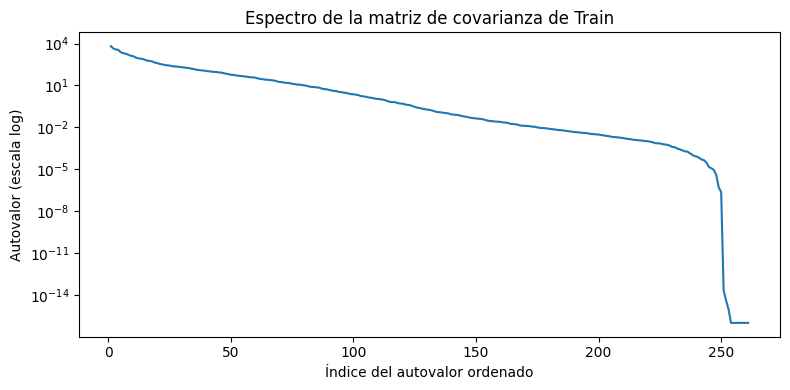

In [10]:
D = X_train_imp.to_numpy(dtype=float)
n_train, d_train = D.shape

rank_D = np.linalg.matrix_rank(D)
Gram = D.T @ D
cond_Gram = np.linalg.cond(Gram)

mu_train_rawscale = D.mean(axis=0)
D_centered = D - mu_train_rawscale
Sigma = (D_centered.T @ D_centered) / (n_train - 1)
eigenvalues = np.linalg.eigvalsh(Sigma)
rank_Sigma = np.linalg.matrix_rank(Sigma)

print(f"D ∈ R^({n_train} x {d_train})")
print(f"rank(D) = {rank_D}")
print(f"Deficiencia de rango d-rank(D) = {d_train-rank_D}")
print(f"rank(Sigma) = {rank_Sigma}")
print(f"kappa(D^T D) = {cond_Gram:.6e}")
print(f"Autovalor mínimo de Sigma = {eigenvalues.min():.6e}")
print(f"Autovalor máximo de Sigma = {eigenvalues.max():.6e}")
print(f"Autovalores numéricamente ~0 (<1e-10): {(eigenvalues < 1e-10).sum()}")

plt.figure(figsize=(8, 4))
positive_eigs = np.clip(eigenvalues, 1e-16, None)
plt.semilogy(np.arange(1, d_train + 1), positive_eigs[::-1])
plt.xlabel("Índice del autovalor ordenado")
plt.ylabel("Autovalor (escala log)")
plt.title("Espectro de la matriz de covarianza de Train")
plt.tight_layout()
plt.show()

### Interpretación del análisis espectral

Un número de condición muy grande significa que pequeñas perturbaciones en los datos pueden producir variaciones grandes en soluciones basadas en $(X^TX)^{-1}$. Además, una deficiencia de rango confirma que la estandarización por sí sola **no puede** arreglar dependencias lineales exactas. Por eso, en etapas posteriores se usa pseudoinversa o regularización de Tikhonov/Ridge cuando se necesita invertir una matriz de covarianza.

## 6. E) Transformaciones espaciales

### 6.1 Mean Centering e invarianza traslacional

Sea

$$
Z=X-\mathbf{1}\mu^T,
\qquad
\mu=\frac{1}{n}\sum_{i=1}^{n}x_i.
$$

La covarianza no cambia si trasladamos todos los puntos por el mismo vector $a$:

$$
\operatorname{Cov}(X+a)
=E[(X+a-E[X+a])(X+a-E[X+a])^T]
=\operatorname{Cov}(X).
$$

Por tanto,

$$
\operatorname{tr}(\Sigma_{X+a})=\operatorname{tr}(\Sigma_X).
$$

El rastro representa la suma de las varianzas marginales, es decir, la dispersión total a lo largo de los ejes coordenados.


In [11]:
# Parámetros ajustados SOLO con Train.
mu_train = X_train_imp.mean(axis=0)
sigma_train = X_train_imp.std(axis=0, ddof=0)

# Ya se eliminaron columnas constantes, pero mantenemos protección numérica.
sigma_train_safe = sigma_train.mask(sigma_train < 1e-12, 1.0)

X_train_centered = X_train_imp - mu_train
X_test_centered = X_test_imp - mu_train

X_train_z = X_train_centered / sigma_train_safe
X_test_z = X_test_centered / sigma_train_safe

# Verificación de media cero en Train.
max_abs_mean_centered = np.abs(X_train_centered.mean(axis=0)).max()
max_abs_mean_z = np.abs(X_train_z.mean(axis=0)).max()

Sigma_before = np.cov(X_train_imp.to_numpy(), rowvar=False, ddof=1)
Sigma_after_center = np.cov(X_train_centered.to_numpy(), rowvar=False, ddof=1)

trace_before = np.trace(Sigma_before)
trace_after = np.trace(Sigma_after_center)

print(f"max |media| después de centrar Train = {max_abs_mean_centered:.3e}")
print(f"max |media| después de Z-score       = {max_abs_mean_z:.3e}")
print(f"tr(Sigma antes)   = {trace_before:.12f}")
print(f"tr(Sigma centrada)= {trace_after:.12f}")
print(f"Diferencia absoluta= {abs(trace_before-trace_after):.3e}")

max |media| después de centrar Train = 1.066e-14
max |media| después de Z-score       = 4.404e-16
tr(Sigma antes)   = 41555.814411399711
tr(Sigma centrada)= 41555.814411399711
Diferencia absoluta= 0.000e+00


### 6.2 Estandarización y condicionamiento

La estandarización

$$
z_{ij}=\frac{x_{ij}-\mu_j}{\sigma_j}
$$

elimina la dominancia artificial producida por unidades heterogéneas. Sin embargo, si existen dependencias lineales exactas, el Hessiano $H=X^TX/n$ puede seguir siendo singular. En ese caso Ridge reemplaza

$$
H \longmapsto H_\lambda=H+\lambda I,
$$

y desplaza todos los autovalores: $\lambda_i(H_\lambda)=\lambda_i(H)+\lambda>0$.


In [12]:
Z_train = X_train_z.to_numpy(dtype=float)
H_z = (Z_train.T @ Z_train) / len(Z_train)
cond_H_z = np.linalg.cond(H_z)

lambda_ridge = 1e-2 * np.trace(H_z) / H_z.shape[0]
H_ridge = H_z + lambda_ridge * np.eye(H_z.shape[0])
cond_H_ridge = np.linalg.cond(H_ridge)

print(f"kappa(H estandarizado)       = {cond_H_z:.6e}")
print(f"lambda Ridge                 = {lambda_ridge:.6e}")
print(f"kappa(H + lambda I)          = {cond_H_ridge:.6e}")

kappa(H estandarizado)       = 1.973114e+18
lambda Ridge                 = 9.808429e-03
kappa(H + lambda I)          = 2.066544e+03


## 7. B) Detección multivariada de ruido con Mahalanobis

Para cada observación estandarizada se calcula

$$
D_M(x)=\sqrt{(x-\mu)^T\Sigma^{-1}(x-\mu)}.
$$

Como la covarianza de este dataset conserva algunas dependencias lineales, usar una inversa ordinaria sería numéricamente inestable. Se utiliza una covarianza regularizada

$$
\Sigma_\lambda=\Sigma+\lambda I
$$

y su pseudoinversa. Esto no cambia la definición conceptual de Mahalanobis; es una estabilización necesaria para este conjunto de alta dimensión.

Bajo normalidad multivariada ideal, $D_M^2$ se aproxima a una $\chi^2_d$. Como criterio tipo $3\sigma$ se usa la aproximación

$$
D_M^2 > d+3\sqrt{2d}.
$$

Los registros detectados se **marcan para revisión**, no se eliminan automáticamente: en medicina, un valor extremo puede ser precisamente el patrón clínico que interesa clasificar.


Dimensión d = 261
Umbral aproximado de Mahalanobis = 18.15329
Registros marcados = 61 de 360


,indice_train,Clase,Mahalanobis,outlier_3sigma_aprox
209,209,5,18.91710,True
107,107,1,18.91648,True
118,118,1,18.91633,True
97,97,10,18.91438,True
268,268,1,18.91244,True
50,50,1,18.91224,True
101,101,3,18.91190,True
184,184,9,18.91182,True
144,144,2,18.91176,True
9,9,1,18.91175,True


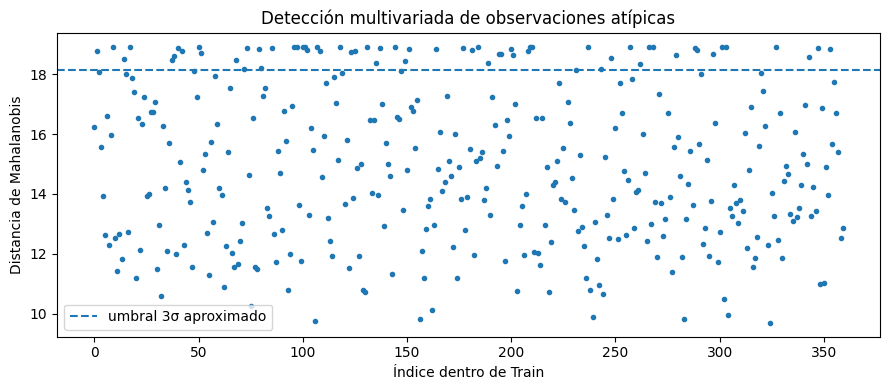

In [13]:
Sigma_z = np.cov(Z_train, rowvar=False, ddof=1)
d = Sigma_z.shape[0]

lambda_cov = 1e-3 * np.trace(Sigma_z) / d
Sigma_reg = Sigma_z + lambda_cov * np.eye(d)
Sigma_inv = np.linalg.pinv(Sigma_reg, rcond=1e-10)

mu_z = Z_train.mean(axis=0)
delta = Z_train - mu_z
DM2 = np.einsum("ij,jk,ik->i", delta, Sigma_inv, delta)
DM = np.sqrt(np.maximum(DM2, 0.0))

threshold2 = d + 3 * np.sqrt(2 * d)
threshold_DM = np.sqrt(threshold2)
outlier_mask = DM > threshold_DM
outlier_idx = np.where(outlier_mask)[0]

outlier_table = pd.DataFrame({
    "indice_train": np.arange(len(DM)),
    "Clase": y_train.to_numpy(),
    "Mahalanobis": DM,
    "outlier_3sigma_aprox": outlier_mask,
}).sort_values("Mahalanobis", ascending=False)

print(f"Dimensión d = {d}")
print(f"Umbral aproximado de Mahalanobis = {threshold_DM:.5f}")
print(f"Registros marcados = {outlier_mask.sum()} de {len(DM)}")
display(outlier_table.head(20).round(5))

plt.figure(figsize=(9, 4))
plt.plot(np.arange(len(DM)), DM, ".")
plt.axhline(threshold_DM, linestyle="--", label="umbral 3σ aproximado")
plt.xlabel("Índice dentro de Train")
plt.ylabel("Distancia de Mahalanobis")
plt.title("Detección multivariada de observaciones atípicas")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretación de los outliers

El número de candidatos puede ser mayor que el 0.27 % esperado bajo una normal multivariada ideal. Eso no implica que el código esté mal: el dataset Arrhythmia mezcla múltiples clases clínicas, variables binarias y continuas, fuerte correlación y distribuciones no gaussianas. Por tanto, el umbral $\chi^2/3\sigma$ debe interpretarse como un **filtro diagnóstico**, no como una regla automática de borrado.

Eliminar estos pacientes podría borrar precisamente arritmias poco frecuentes. La decisión prudente es conservarlos y, si el objetivo posterior lo exige, estudiar su influencia por clase y con métodos robustos.

## 8. F) Análisis crítico de estabilidad

El flujo implementado sigue deliberadamente el orden solicitado:

\[
\boxed{\text{auditoría de faltantes}
\rightarrow
\text{tratamiento/imputación}
\rightarrow
X_{\mathrm{complete}}
\rightarrow
\text{estratificación}}
\]

Primero se elimina `j_angle` debido a su porcentaje extremo de ausencia. Los faltantes escasos de los demás atributos se reconstruyen mediante un MICE básico con regresiones Ridge y una componente residual estocástica. Antes de separar los datos se verifica explícitamente que `X_complete` no contenga ningún `NaN`.

La imputación por media se mantiene únicamente como comparación, porque preserva la media pero reduce determinísticamente la varianza. El esquema multivariado utiliza información de otros atributos y evita que todas las observaciones faltantes coincidan en un único valor central.

Una vez completada la matriz se realiza el particionamiento estratificado, obteniendo `X_train_imp`, `X_test_imp`, `y_train` y `y_test`. Las transformaciones posteriores —centrado, estandarización, covarianza y regularización— sí se calculan usando los parámetros de `Train` y se aplican posteriormente a `Test`.

Desde el punto de vista algebraico, centrar los datos no modifica la covarianza ni su rastro; solo traslada el origen al centro de gravedad. La estandarización sí modifica las escalas y reduce la anisotropía debida a unidades heterogéneas. Sin embargo, no elimina dependencias lineales exactas, por lo cual \(X^TX\) o \(\Sigma\) pueden seguir siendo singulares o casi singulares.

La regularización de Tikhonov/Ridge,

\[
H_\lambda=H+\lambda I,
\]

desplaza el espectro y reduce el número de condición, estabilizando la inversión matricial y la dinámica de optimización.

Finalmente, la distancia de Mahalanobis se calcula sobre el espacio estandarizado y con covarianza regularizada. Los puntos extremos se marcan, pero no se eliminan automáticamente, porque en un problema clínico multiclase una observación alejada puede representar una arritmia poco frecuente y no necesariamente ruido.

> Nota: completar toda la matriz antes del `Train/Test split` hace que la imputación utilice información de los predictores de todas las observaciones. Se conserva aquí porque ese es el orden solicitado para la práctica; para estimar rendimiento predictivo fuera de muestra de forma estricta, el imputador debería ajustarse únicamente con `Train`.


## 9. Resumen de decisiones de preprocesamiento

| Problema | Decisión | Justificación |
|---|---|---|
| `j_angle` con ausencia extrema | Eliminar atributo antes de estratificar | La mayor parte de la columna tendría que ser reconstruida artificialmente. |
| Faltantes escasos en otros atributos | Imputación multivariada iterativa antes de estratificar | Completa la matriz aprovechando relaciones entre atributos. |
| Imputación por media | Solo demostración, no estrategia final | Conserva la media pero reduce varianza y atenúa covarianzas. |
| Filas incompletas | No eliminación masiva | Se conservaron los 452 pacientes y se completaron sus atributos faltantes. |
| Verificación de completitud | `X_complete.isna().sum().sum() == 0` | Garantiza que la estratificación recibe datos ya tratados. |
| Estratificación | Aplicar después de construir `X_complete` | Mantiene aproximadamente la proporción de clases sobre una matriz completa. |
| Columnas constantes | Eliminar antes de estratificar | Varianza cero e información discriminante nula. |
| Estandarización | Ajustar con `Train` y aplicar a `Test` | Evita dominancia por escala en las etapas posteriores. |
| Covarianza singular/casi singular | Regularización/pseudoinversa | Mejora estabilidad numérica. |
| Outliers Mahalanobis | Marcar, no borrar automáticamente | En datos clínicos, los extremos pueden ser casos reales de arritmia. |

El flujo central queda:

\[
\boxed{
X_{\mathrm{raw}}
\rightarrow
X_{\mathrm{stage}}
\rightarrow
X_{\mathrm{complete}}
\rightarrow
(X_{\mathrm{train}},X_{\mathrm{test}})
}
\]

y `X_train_imp` y `X_test_imp` ya nacen sin valores faltantes.
